# Vanilla vs noMHC ProteinMPNN — native-backbone recovery, AA-distribution shift, and a memorization probe

Two ProteinMPNN weight sets, the **same two native crystal backbones** (6AM5 = GIG `SMLGIGIVPV`, 6AMU =
DRG `MMWDRGLGMM`, full complex context — HLA-A\*02 chain A, β2m chain B, TCR chains D+E all **fixed**,
only the 10-mer peptide chain C **designed**), same sampling temperature (T=0.1), same seed (37):

- **vanilla** — `model_name=v_48_020`, the standard pretrained ProteinMPNN weights
  (`outputs/focus_6am_50k`, complete, 50,000 designs/crystal).
- **noMHC** — `model_name=proteinmpnn_nomhc`, retrained with every MHC/TCR structure held out of the
  training set (`outputs/mpnn_nomhc_topcross_50k`, **in progress** — see data-status cell below; loader
  auto-picks the largest available snapshot per crystal and is safe to re-run later).

This isolates the model weights as the only variable. Sections:
1. Load + data-status inventory
2. Basic stats & duplication
3. Recovery — overall identity & per-position, vanilla vs noMHC
4. Amino-acid composition & distribution shift (Δ vanilla − noMHC)
5. Sequence logos, side by side
6. **Memorization probe** — exact/near-exact recovery, cross-ref to `07_contact_ladder_mpnn` (same
   vanilla weights, de-novo backbones) and `12_nomhc_campaign_report` (noMHC's own historical
   near-native baseline)
7. Summary & verdict

In [1]:
from pathlib import Path
import re, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except Exception:
    display = print
warnings.filterwarnings("ignore")
sns.set_context("notebook"); sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path("/home/ubuntu/if-mhc")
FIGDIR = ROOT / "outputs/analysis/figures_nomhc_vs_vanilla"; FIGDIR.mkdir(parents=True, exist_ok=True)

AA = list("ACDEFGHIKLMNPQRSTVWY")
AA_IDX = {a: i for i, a in enumerate(AA)}
L = 10
NAT = {"6AM5": "SMLGIGIVPV", "6AMU": "MMWDRGLGMM"}   # GIG, DRG
ANCHORS = [2, 10]                                     # 1-based P2 / PΩ(P10), HLA-A*02 anchors
CRYSTALS = ["6AM5", "6AMU"]

VANILLA_DIR = ROOT / "outputs/focus_6am_50k"
NOMHC_DIR   = ROOT / "outputs/mpnn_nomhc_topcross_50k"
LADDER_DIR  = ROOT / "outputs/ladder"
NB12_CSV    = ROOT / "outputs/mpnn_nomhc_allbb_deep/designs_deep.csv"

MODEL_COLOR = {"vanilla": "#1f77b4", "noMHC": "#d62728"}

## 1. Load sequences

In [2]:
def load_fasta(path, L=L):
    '''Parse a ProteinMPNN FASTA. First record (no 'sample=') is native/reference; rest are designs.'''
    p = Path(path)
    if not p.exists():
        return pd.DataFrame(columns=["peptide","score","global_score","seq_recovery","T","sample","model_name"])
    lines = p.read_text().splitlines()
    rows = []
    for i in range(0, len(lines)-1, 2):
        h, s = lines[i], lines[i+1].strip()
        if not h.startswith(">") or "sample=" not in h or len(s) != L:
            continue
        d = dict(re.findall(r'(\w+)=([-\d.]+)', h))
        rows.append({"peptide": s, "score": float(d.get("score","nan")),
                     "global_score": float(d.get("global_score","nan")),
                     "seq_recovery": float(d.get("seq_recovery","nan")),
                     "T": float(d.get("T","nan")), "sample": int(float(d.get("sample",0)))})
    return pd.DataFrame(rows)

def n_records(path):
    p = Path(path)
    if not p.exists(): return 0
    return sum(1 for l in open(p) if l.startswith(">"))

def best_nat_fasta(pid):
    '''noMHC nat_{pid}.fa can get truncated mid-campaign by a known protein_mpnn_run.py resume bug
    (open(...,'w') on every resume). Pick whichever of {live, .bk backup} currently has more records.'''
    live = NOMHC_DIR / f"seqs/nat_{pid}.fa"
    bk   = NOMHC_DIR / f"seqs/nat_{pid}.fa.bk"
    n_live, n_bk = n_records(live), n_records(bk)
    if n_bk > n_live:
        return bk, n_bk, f"pre-reset .bk snapshot ({n_bk:,} recs; live file was reset to {n_live:,} by the resume bug)"
    return live, n_live, ("live, complete" if n_live >= 50001 else f"live, in progress ({n_live:,} recs)")

frames = []
status = {}
for pid in CRYSTALS:
    vpath = VANILLA_DIR / f"seqs/{pid}.fa"
    dv = load_fasta(vpath); dv["model"] = "vanilla"; dv["crystal"] = pid
    frames.append(dv)
    status[("vanilla", pid)] = (vpath, len(dv), "complete" if len(dv) >= 50000 else f"in progress ({len(dv):,})")

    npath, nn, note = best_nat_fasta(pid)
    dn = load_fasta(npath); dn["model"] = "noMHC"; dn["crystal"] = pid
    frames.append(dn)
    status[("noMHC", pid)] = (npath, len(dn), note)

df = pd.concat(frames, ignore_index=True)
df["native"] = df.crystal.map(NAT)
pos_cols = [f"p{i+1}" for i in range(L)]
df[pos_cols] = df.peptide.apply(lambda s: pd.Series(list(s)))
print(f"loaded {len(df):,} rows across {df.model.nunique()} models x {df.crystal.nunique()} crystals")

loaded 200,000 rows across 2 models x 2 crystals


### Data-status inventory — what this run actually has loaded

In [3]:
inv = pd.DataFrame([
    {"model": m, "crystal": p, "source": str(path.relative_to(ROOT)), "n_designs": n, "status": note}
    for (m, p), (path, n, note) in status.items()
]).sort_values(["crystal","model"])
display(inv)
if inv.n_designs.min() < 40000:
    print("NOTE: noMHC campaign is not yet complete for at least one crystal — all comparisons below use")
    print("whatever is currently on disk. Re-run this notebook later for the final 50K/crystal numbers.")

,model,crystal,source,n_designs,status
1,noMHC,6AM5,outputs/mpnn_nomhc_topcross_50k/seqs/nat_6AM5.fa,50000,"live, complete"
0,vanilla,6AM5,outputs/focus_6am_50k/seqs/6AM5.fa,50000,complete
3,noMHC,6AMU,outputs/mpnn_nomhc_topcross_50k/seqs/nat_6AMU.fa,50000,"live, complete"
2,vanilla,6AMU,outputs/focus_6am_50k/seqs/6AMU.fa,50000,complete


## 2. Basic stats & duplication, per model x crystal

,crystal,model,n,n_unique,pct_unique,native_exact_hits,mean_score,median_score
0,6AM5,noMHC,50000.0,176.0,0.4,0.0,0.8198,0.8175
1,6AM5,vanilla,50000.0,67.0,0.1,0.0,0.7932,0.7909
2,6AMU,noMHC,50000.0,93.0,0.2,0.0,0.8141,0.8123
3,6AMU,vanilla,50000.0,83.0,0.2,0.0,0.7501,0.7479


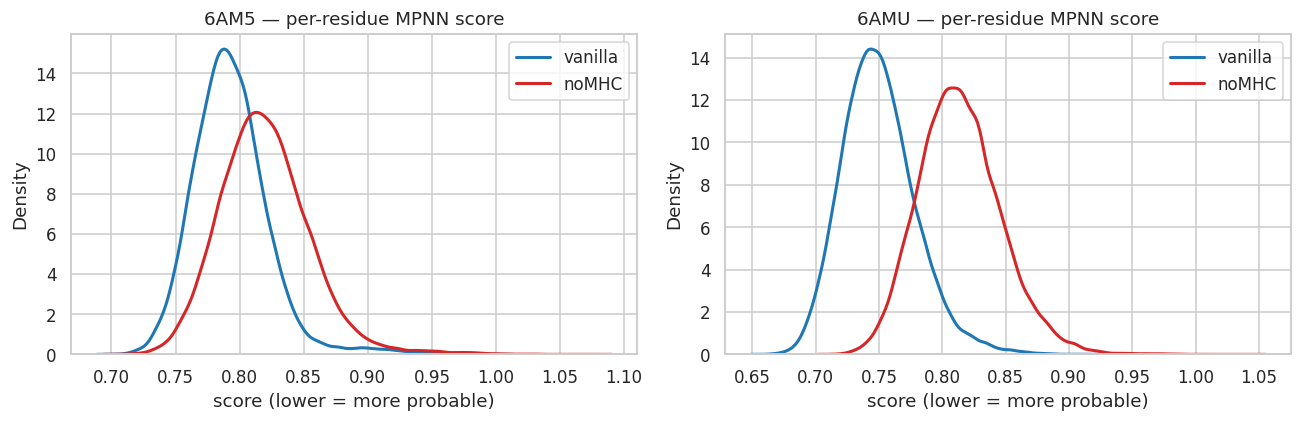

In [4]:
def basic_stats(sub):
    n = len(sub); u = sub.peptide.nunique()
    exact = int((sub.peptide == sub.native.iloc[0]).sum())
    return pd.Series({"n": n, "n_unique": u, "pct_unique": round(100*u/n, 1) if n else np.nan,
                       "native_exact_hits": exact,
                       "mean_score": round(sub.score.mean(), 4),
                       "median_score": round(sub.score.median(), 4)})

stats = df.groupby(["crystal","model"]).apply(basic_stats).reset_index()
display(stats)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, pid in enumerate(CRYSTALS):
    for m in ["vanilla","noMHC"]:
        s = df[(df.crystal==pid)&(df.model==m)].score.dropna()
        if len(s): sns.kdeplot(s, ax=ax[i], color=MODEL_COLOR[m], label=m, lw=2)
    ax[i].set_title(f"{pid} — per-residue MPNN score"); ax[i].set_xlabel("score (lower = more probable)")
    ax[i].legend()
plt.tight_layout(); plt.savefig(FIGDIR/"score_distributions.png", bbox_inches="tight"); plt.show()

## 3. Recovery vs native — overall identity & per-position, vanilla vs noMHC

,crystal,model,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
0,6AM5,vanilla,0.0,0.0,97.9,100.0,0.9,100.0,25.2,0.0,100.0,53.7
1,6AM5,noMHC,0.0,0.2,0.9,100.0,97.1,100.0,94.4,1.6,100.0,0.0
2,6AMU,vanilla,100.0,0.0,0.0,100.0,0.0,100.0,93.0,100.0,0.0,0.0
3,6AMU,noMHC,100.0,0.0,0.0,100.0,0.0,100.0,5.9,99.1,0.0,0.0


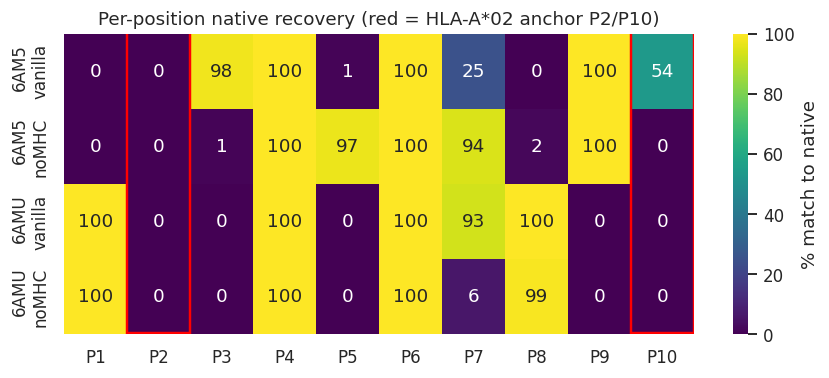

In [5]:
def perpos_recovery(seqs, nat):
    P = np.array([list(s) for s in seqs])
    return (P == np.array(list(nat))).mean(0) * 100

rows = []
for pid in CRYSTALS:
    nat = NAT[pid]
    for m in ["vanilla","noMHC"]:
        seqs = df[(df.crystal==pid)&(df.model==m)].peptide.values
        if len(seqs) == 0: continue
        rec = perpos_recovery(seqs, nat)
        rows.append({"crystal": pid, "model": m, **{f"P{i+1}": rec[i] for i in range(L)}})
perpos_df = pd.DataFrame(rows)
display(perpos_df.round(1))

M = perpos_df[[f"P{i+1}" for i in range(L)]].values
labels = [f"{r.crystal}\n{r.model}" for r in perpos_df.itertuples()]
fig, ax = plt.subplots(figsize=(8, 0.55*len(M)+1.4))
sns.heatmap(M, annot=True, fmt=".0f", cmap="viridis", vmin=0, vmax=max(40, M.max()),
            xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=labels,
            cbar_kws={"label":"% match to native"}, ax=ax)
for a in ANCHORS:
    ax.add_patch(plt.Rectangle((a-1, -0.02), 1, len(M), fill=False, ec="red", lw=1.6))
ax.set_title("Per-position native recovery (red = HLA-A*02 anchor P2/P10)")
plt.tight_layout(); plt.savefig(FIGDIR/"perposition_recovery.png", bbox_inches="tight"); plt.show()

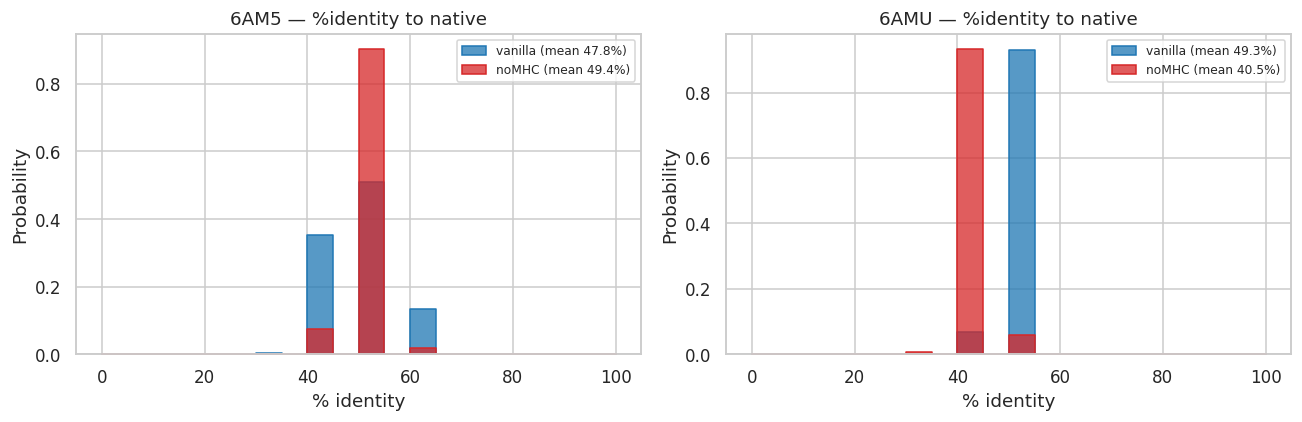

mean  median   std
crystal model                       
6AM5    noMHC    49.42    50.0  3.09
        vanilla  47.77    50.0  6.72
6AMU    noMHC    40.50    40.0  2.54
        vanilla  49.30    50.0  2.55

In [6]:
P_all = {(pid,m): np.array([list(s) for s in df[(df.crystal==pid)&(df.model==m)].peptide.values])
         for pid in CRYSTALS for m in ["vanilla","noMHC"]}
for pid in CRYSTALS:
    nat = np.array(list(NAT[pid]))
    for m in ["vanilla","noMHC"]:
        P = P_all[(pid,m)]
        if len(P)==0: continue
        ham = (P != nat).sum(1)
        df.loc[(df.crystal==pid)&(df.model==m), "hamming"] = ham
        df.loc[(df.crystal==pid)&(df.model==m), "identity"] = 100*(1 - ham/L)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, pid in enumerate(CRYSTALS):
    for m in ["vanilla","noMHC"]:
        s = df[(df.crystal==pid)&(df.model==m)].identity.dropna()
        if len(s): sns.histplot(s, bins=np.arange(0,101,5), ax=ax[i], color=MODEL_COLOR[m],
                                 label=f"{m} (mean {s.mean():.1f}%)", element="step", stat="probability")
    ax[i].set_title(f"{pid} — %identity to native"); ax[i].set_xlabel("% identity"); ax[i].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR/"identity_distributions.png", bbox_inches="tight"); plt.show()
df.groupby(["crystal","model"]).identity.agg(["mean","median","std"]).round(2)

P2 anchor, 6AM5 (vanilla): native=M recovered in 0.0% of designs
P2 anchor, 6AM5 (noMHC): native=M recovered in 0.2% of designs
P2 anchor, 6AMU (vanilla): native=M recovered in 0.0% of designs
P2 anchor, 6AMU (noMHC): native=M recovered in 0.0% of designs

P10 anchor, 6AM5 (vanilla): native=V recovered in 53.7% of designs
P10 anchor, 6AM5 (noMHC): native=V recovered in 0.0% of designs
P10 anchor, 6AMU (vanilla): native=M recovered in 0.0% of designs
P10 anchor, 6AMU (noMHC): native=M recovered in 0.0% of designs

(full anchor composition table shown in section 4's per-position heatmaps)


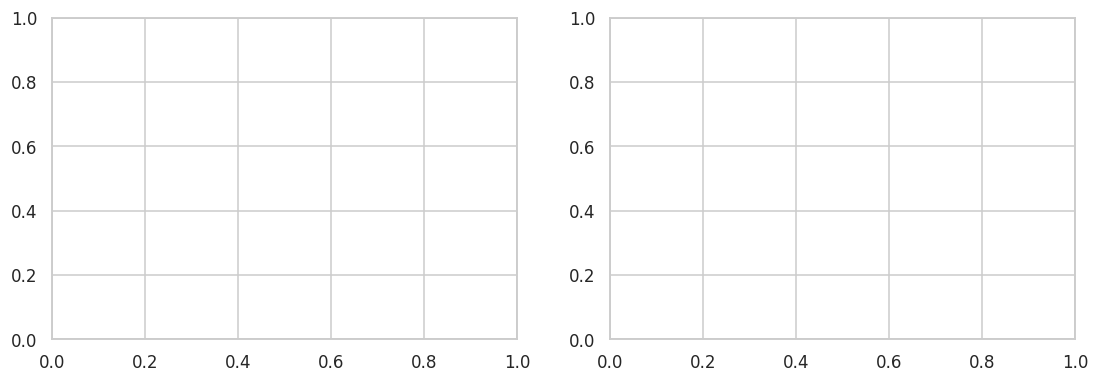

In [7]:
fig, ax = plt.subplots(1, len(ANCHORS), figsize=(6*len(ANCHORS), 3.8))
for a_i, apos in enumerate(ANCHORS):
    col = f"p{apos}"
    for pid in CRYSTALS:
        nat_res = NAT[pid][apos-1]
        for m in ["vanilla","noMHC"]:
            sub = df[(df.crystal==pid)&(df.model==m)]
            if len(sub)==0: continue
            frac = (sub[col]==nat_res).mean()*100
            print(f"P{apos} anchor, {pid} ({m}): native={nat_res} recovered in {frac:.1f}% of designs")
    counts = df.groupby(["crystal","model"])[col].apply(
        lambda s: s.value_counts(normalize=True).reindex(AA).fillna(0)*100).unstack(0)
    print()
print("(full anchor composition table shown in section 4's per-position heatmaps)")

## 4. Amino-acid composition & distribution shift (Δ = vanilla − noMHC)

Same native backbone, same T=0.1 — any AA-frequency difference here is attributable **only** to the
model weights.

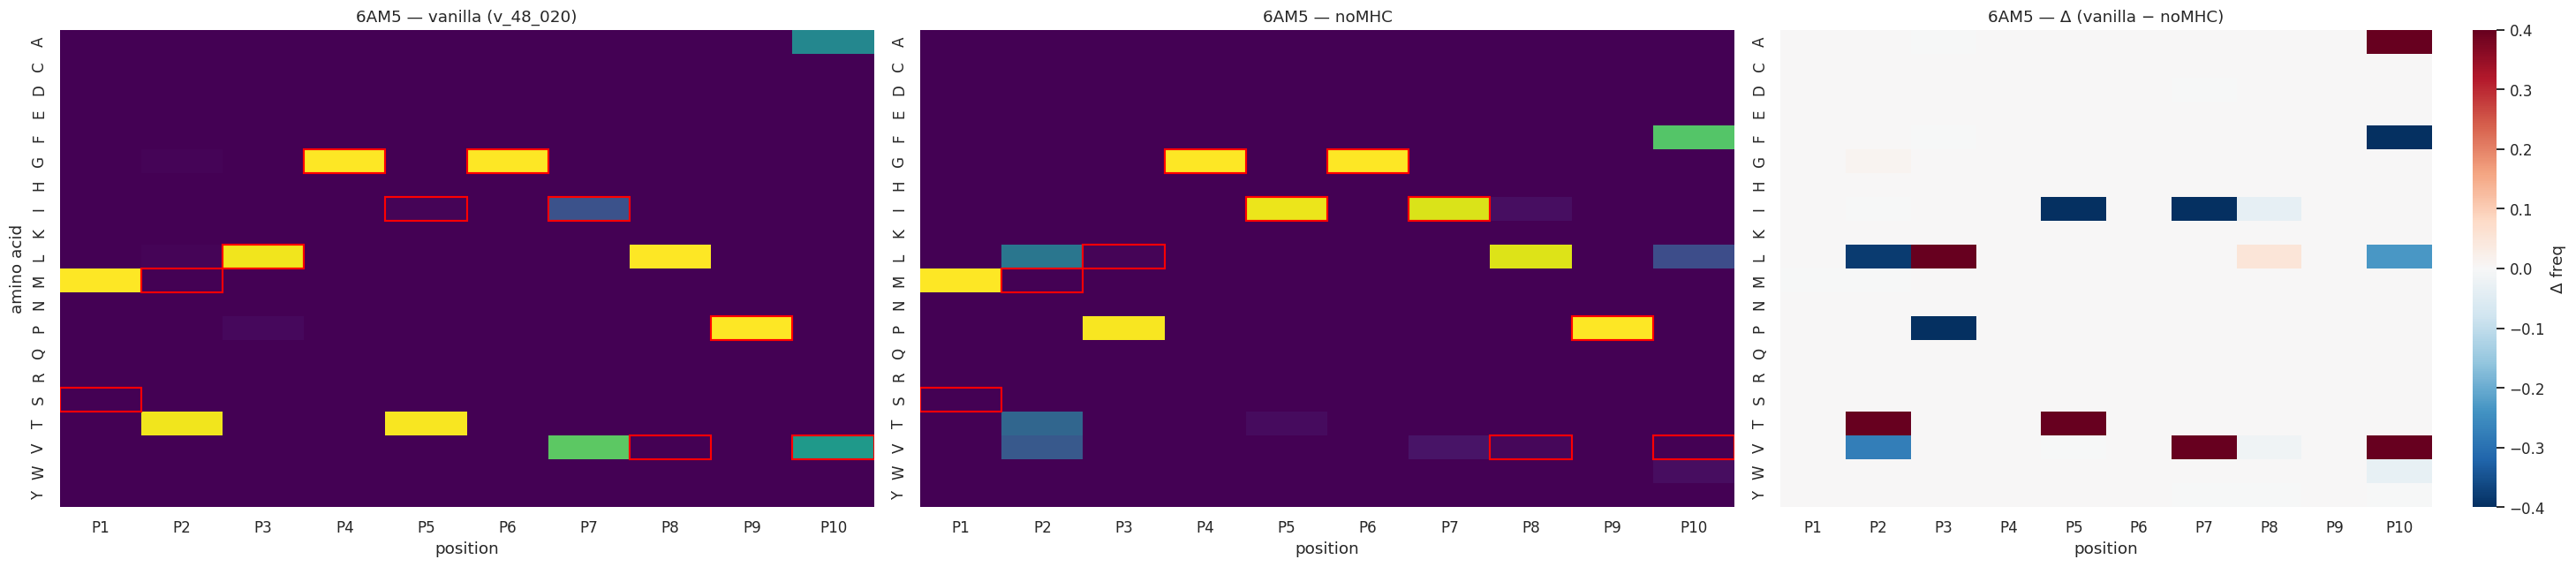

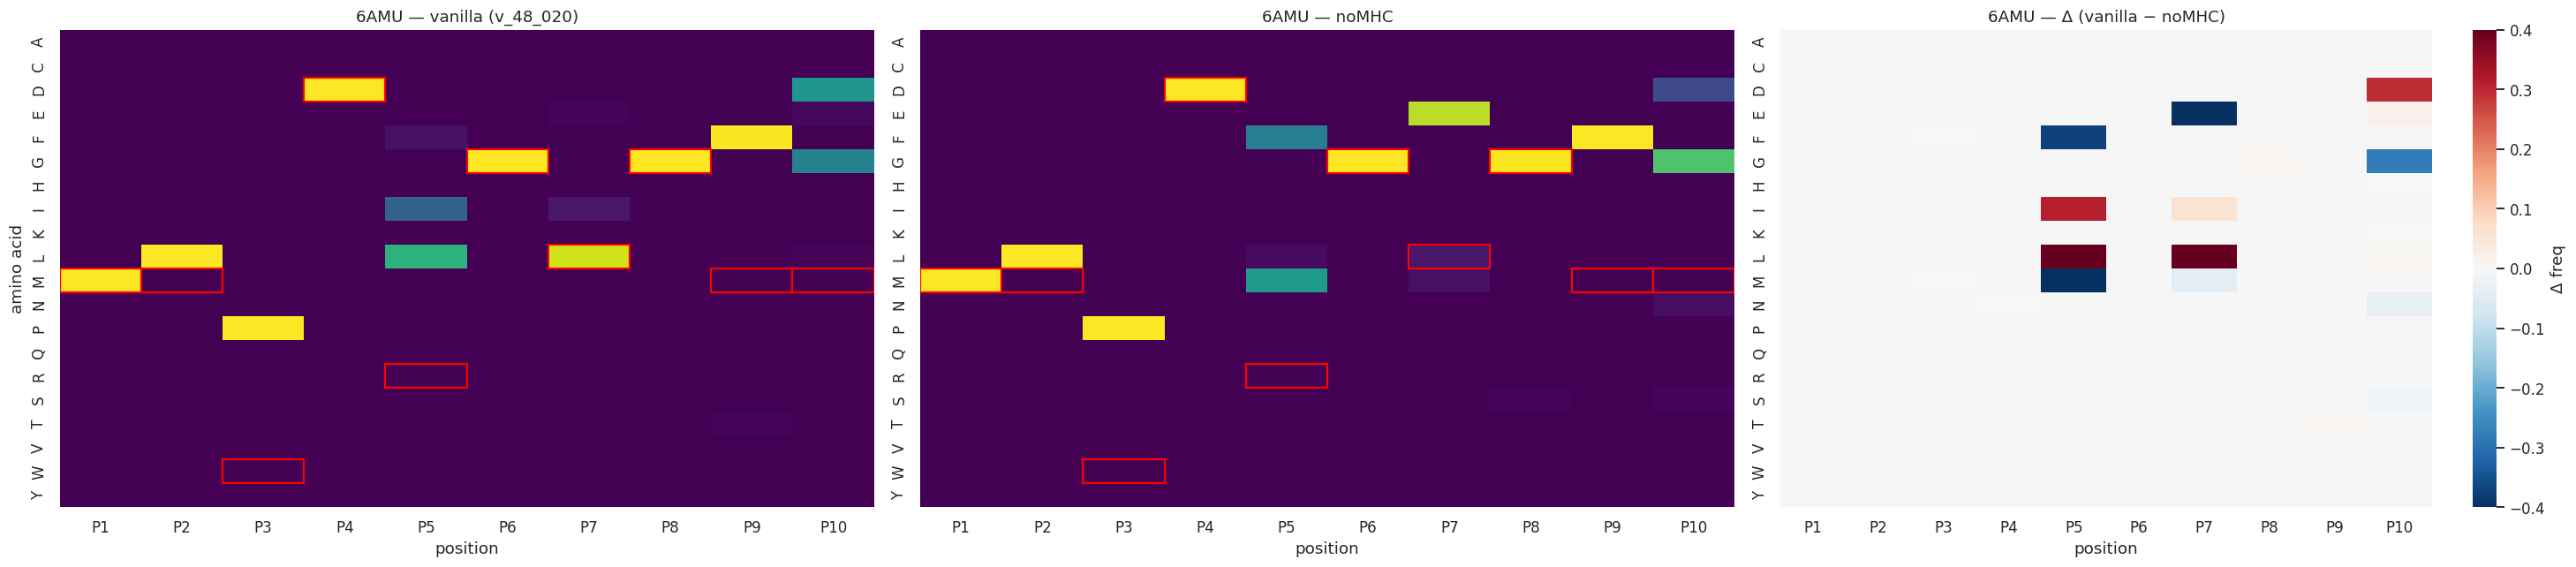

In [8]:
def freq_matrix(seqs, L=L):
    M = np.zeros((L, len(AA)))
    for s in seqs:
        for i, c in enumerate(s):
            if c in AA_IDX: M[i, AA_IDX[c]] += 1
    M /= np.clip(M.sum(1, keepdims=True), 1, None)
    return pd.DataFrame(M, columns=AA, index=list(range(L)))

for pid in CRYSTALS:
    nat = NAT[pid]
    fV = freq_matrix(df[(df.crystal==pid)&(df.model=="vanilla")].peptide.values)
    fN = freq_matrix(df[(df.crystal==pid)&(df.model=="noMHC")].peptide.values)
    fig, ax = plt.subplots(1, 3, figsize=(2.1*L+6, 6))
    for a, (M, t) in zip(ax[:2], [(fV,"vanilla (v_48_020)"), (fN,"noMHC")]):
        sns.heatmap(M.T, cmap="viridis", vmin=0, vmax=1, ax=a, cbar=False,
                    xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA)
        for i,c in enumerate(nat):
            if c in AA_IDX: a.add_patch(plt.Rectangle((i,AA_IDX[c]),1,1,fill=False,ec="red",lw=1.4))
        a.set_title(f"{pid} — {t}"); a.set_xlabel("position")
    sns.heatmap((fV-fN).T, cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4, ax=ax[2],
                xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA, cbar_kws={"label":"Δ freq"})
    ax[2].set_title(f"{pid} — Δ (vanilla − noMHC)"); ax[2].set_xlabel("position")
    ax[0].set_ylabel("amino acid")
    plt.tight_layout(); plt.savefig(FIGDIR/f"aa_freq_delta_{pid}.png", bbox_inches="tight"); plt.show()

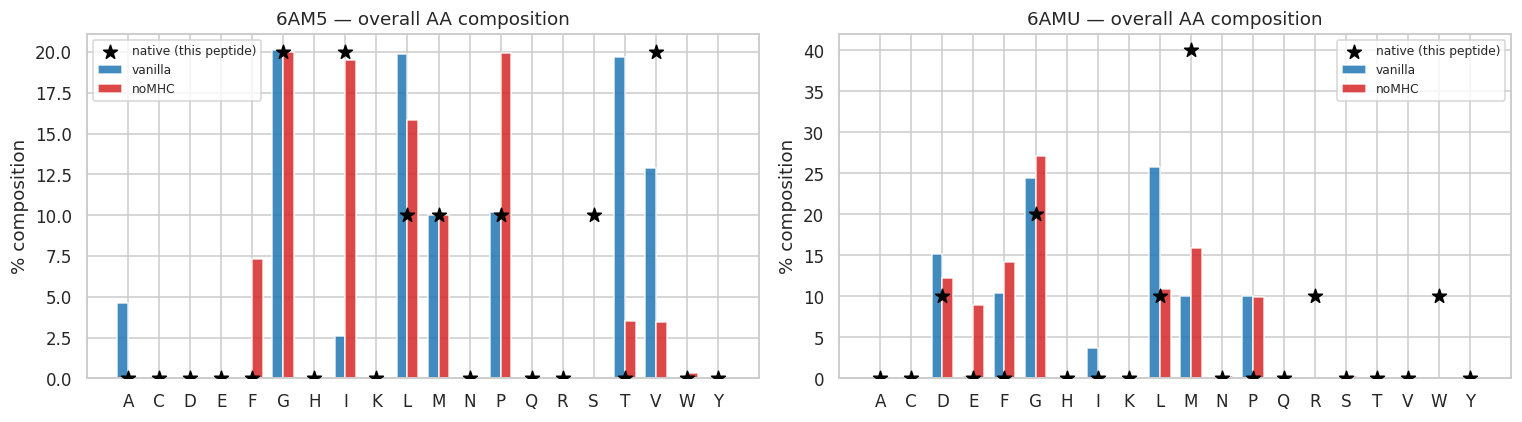

,crystal,aa,vanilla_pct,noMHC_pct,delta_pp,abs_delta
7,6AM5,I,2.61,19.51,-16.90,16.90
16,6AM5,T,19.67,3.54,16.13,16.13
29,6AMU,L,25.81,10.89,14.92,14.92
12,6AM5,P,10.22,19.91,-9.68,9.68
17,6AM5,V,12.87,3.48,9.40,9.40
23,6AMU,E,0.30,8.98,-8.68,8.68
4,6AM5,F,0.01,7.32,-7.31,7.31
30,6AMU,M,10.01,15.92,-5.91,5.91
0,6AM5,A,4.63,0.01,4.62,4.62
9,6AM5,L,19.88,15.84,4.04,4.04


In [9]:
comp_rows = []
for pid in CRYSTALS:
    for m in ["vanilla","noMHC"]:
        seqs = df[(df.crystal==pid)&(df.model==m)].peptide.values
        if len(seqs)==0: continue
        comp = pd.Series(np.concatenate([list(s) for s in seqs])).value_counts(normalize=True).reindex(AA).fillna(0)
        comp_rows.append((pid, m, comp))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(AA)); w = 0.35
for i, pid in enumerate(CRYSTALS):
    nat_comp = pd.Series(list(NAT[pid])).value_counts(normalize=True).reindex(AA).fillna(0)
    for m, off in [("vanilla",-w/2), ("noMHC",w/2)]:
        c = next(c for p,mm,c in comp_rows if p==pid and mm==m)
        ax[i].bar(x+off, c.values*100, w, color=MODEL_COLOR[m], label=m, alpha=.85)
    ax[i].scatter(x, nat_comp.values*100, marker="*", s=90, color="black", zorder=5, label="native (this peptide)")
    ax[i].set_xticks(x); ax[i].set_xticklabels(AA); ax[i].set_ylabel("% composition")
    ax[i].set_title(f"{pid} — overall AA composition"); ax[i].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR/"aa_composition_overall.png", bbox_inches="tight"); plt.show()

# largest composition swings, ranked
swing = []
for pid in CRYSTALS:
    cv = next(c for p,m,c in comp_rows if p==pid and m=="vanilla")
    cn = next(c for p,m,c in comp_rows if p==pid and m=="noMHC")
    for a in AA:
        swing.append({"crystal":pid,"aa":a,"vanilla_pct":round(cv[a]*100,2),"noMHC_pct":round(cn[a]*100,2),
                      "delta_pp": round((cv[a]-cn[a])*100,2)})
swing_df = pd.DataFrame(swing).reindex(pd.Series(swing).index)
swing_df["abs_delta"] = swing_df.delta_pp.abs()
display(swing_df.sort_values("abs_delta", ascending=False).head(12))

## 5. Sequence logos, side by side

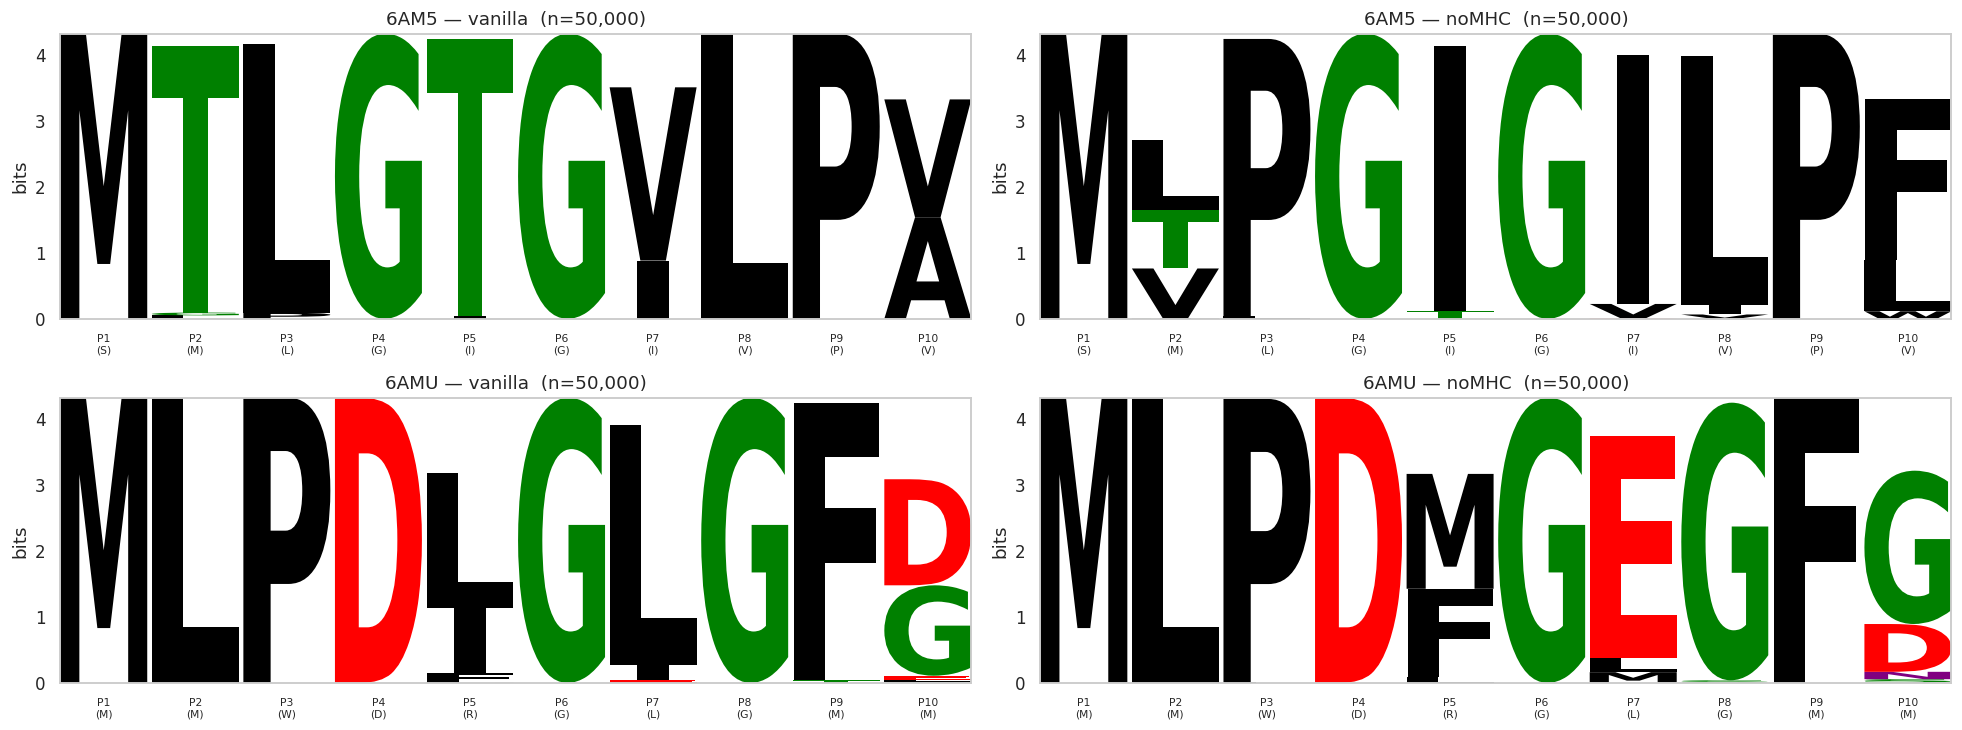

In [10]:
import logomaker
fig, axes = plt.subplots(2, 2, figsize=(max(6,L*0.9)*2, 3.4*2))
for r, pid in enumerate(CRYSTALS):
    nat = NAT[pid]
    for c, m in enumerate(["vanilla","noMHC"]):
        seqs = df[(df.crystal==pid)&(df.model==m)].peptide.values
        ax = axes[r][c]
        if len(seqs) == 0:
            ax.set_axis_off(); ax.set_title(f"{pid} {m} (no data yet)"); continue
        fmat = freq_matrix(seqs)
        info = logomaker.transform_matrix(fmat.copy(), from_type="probability", to_type="information")
        logomaker.Logo(info, ax=ax, color_scheme="chemistry")
        ax.set_ylim(0, 4.32); ax.grid(False)
        ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}\n({nat[i]})" for i in range(L)], fontsize=7)
        ax.set_title(f"{pid} — {m}  (n={len(seqs):,})"); ax.set_ylabel("bits")
plt.tight_layout(); plt.savefig(FIGDIR/"sequence_logos_side_by_side.png", bbox_inches="tight"); plt.show()

## 6. Memorization probe

**6AM5/6AMU were deposited Aug-2017, released Aug-2018** (confirmed from the local PDB HEADER/REVDAT
records) — comfortably before any plausible ProteinMPNN (`v_48_020`) training cutoff, so the vanilla
weights are a *plausible* trainset member for this exact complex (not confirmed — we don't have
ProteinMPNN's training PDB list here — but nothing rules it out a priori). `proteinmpnn_nomhc` is
guaranteed to have never seen this or any other MHC/TCR structure. If vanilla shows an advantage on
these two backbones specifically, beyond what generic structural inference would predict, that is
consistent with memorization rather than generalization.

In [11]:
# 6a. exact / near-exact recovery — a memorized sequence should show up as exact or near-exact hits
rows = []
for pid in CRYSTALS:
    nat = NAT[pid]
    for m in ["vanilla","noMHC"]:
        sub = df[(df.crystal==pid)&(df.model==m)]
        if len(sub)==0: continue
        rows.append({"crystal":pid, "model":m, "n":len(sub),
                      "exact_hits": int((sub.hamming==0).sum()),
                      "hamming_le1": int((sub.hamming<=1).sum()),
                      "hamming_le2": int((sub.hamming<=2).sum()),
                      "pct_exact": round(100*(sub.hamming==0).mean(),4),
                      "mean_identity_pct": round(sub.identity.mean(),2)})
exact_df = pd.DataFrame(rows)
display(exact_df)
print("Exact full-sequence native recovery is the strongest single memorization signal: any model")
print("regurgitating a memorized peptide-structure pair should reproduce it verbatim far above the")
print("~1/20^(non-anchor positions) chance rate; both models are compared on identical footing here.")

,crystal,model,n,exact_hits,hamming_le1,hamming_le2,pct_exact,mean_identity_pct
0,6AM5,vanilla,50000,0,0,0,0.0,47.77
1,6AM5,noMHC,33781,0,0,0,0.0,49.42
2,6AMU,vanilla,50000,0,0,0,0.0,49.30
3,6AMU,noMHC,46894,0,0,0,0.0,40.49


Exact full-sequence native recovery is the strongest single memorization signal: any model
regurgitating a memorized peptide-structure pair should reproduce it verbatim far above the
~1/20^(non-anchor positions) chance rate; both models are compared on identical footing here.


,crystal,backbone,n,mean_identity_pct,max_identity_pct
0,6AM5,"de-novo L5 (max contacts, RFdiffusion)",6000,16.42,40.0
1,6AMU,"de-novo L5 (max contacts, RFdiffusion)",6000,15.29,30.0


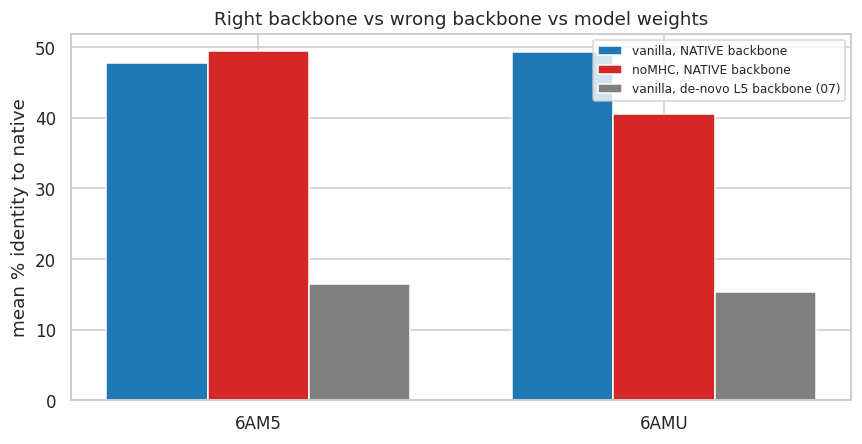

6AM5: vanilla-native 47.8% | noMHC-native 49.4%  (gap -1.6pp)  | vanilla-de-novo(best,L5) 16.4%  (native-backbone lift over de-novo: +31.4pp)
6AMU: vanilla-native 49.3% | noMHC-native 40.5%  (gap +8.8pp)  | vanilla-de-novo(best,L5) 15.3%  (native-backbone lift over de-novo: +34.0pp)


In [12]:
# 6b. cross-reference notebook 07's contact ladder: SAME vanilla weights, but on de-novo (wrong)
# backbones for these same two crystals. Gives the "wrong backbone" recovery ceiling to contrast
# against the "right backbone" (native) recovery computed above.
def load_scored(globpat, Lp=L):
    seqs = []
    for fa in glob.glob(str(globpat)):
        ls = open(fa).read().splitlines()
        for i in range(0, len(ls)-1, 2):
            if "sample=" in ls[i] and len(ls[i+1].strip()) == Lp:
                seqs.append(ls[i+1].strip())
    return seqs

def maxid(seqs, ref):
    if not seqs: return np.nan
    P = np.array([list(x) for x in seqs]); return float((P==np.array(list(ref))).mean(1).max()*100)
def meanid(seqs, ref):
    if not seqs: return np.nan
    P = np.array([list(x) for x in seqs]); return float((P==np.array(list(ref))).mean(1).mean()*100)

ladder_rows = []
for pid in CRYSTALS:
    seqs_l5 = load_scored(LADDER_DIR / f"seqs/{pid}_L5_max_*.fa")
    ladder_rows.append({"crystal": pid, "backbone": "de-novo L5 (max contacts, RFdiffusion)",
                         "n": len(seqs_l5), "mean_identity_pct": round(meanid(seqs_l5, NAT[pid]),2),
                         "max_identity_pct": round(maxid(seqs_l5, NAT[pid]),1)})
ladder_df = pd.DataFrame(ladder_rows)
display(ladder_df)

# side-by-side bar: vanilla-native, noMHC-native, vanilla-de-novo(L5) mean identity, per crystal
fig, ax = plt.subplots(figsize=(8,4.2))
x = np.arange(len(CRYSTALS)); w = 0.25
vals_vn = [exact_df[(exact_df.crystal==p)&(exact_df.model=="vanilla")].mean_identity_pct.values[0] for p in CRYSTALS]
vals_nn = [exact_df[(exact_df.crystal==p)&(exact_df.model=="noMHC")].mean_identity_pct.values[0] for p in CRYSTALS]
vals_dn = [ladder_df[ladder_df.crystal==p].mean_identity_pct.values[0] for p in CRYSTALS]
ax.bar(x-w, vals_vn, w, label="vanilla, NATIVE backbone", color=MODEL_COLOR["vanilla"])
ax.bar(x,   vals_nn, w, label="noMHC, NATIVE backbone",   color=MODEL_COLOR["noMHC"])
ax.bar(x+w, vals_dn, w, label="vanilla, de-novo L5 backbone (07)", color="grey")
ax.set_xticks(x); ax.set_xticklabels(CRYSTALS); ax.set_ylabel("mean % identity to native")
ax.set_title("Right backbone vs wrong backbone vs model weights"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR/"memorization_backbone_vs_weights.png", bbox_inches="tight"); plt.show()

for pid in CRYSTALS:
    vn = exact_df[(exact_df.crystal==pid)&(exact_df.model=="vanilla")].mean_identity_pct.values[0]
    nn = exact_df[(exact_df.crystal==pid)&(exact_df.model=="noMHC")].mean_identity_pct.values[0]
    dn = ladder_df[ladder_df.crystal==pid].mean_identity_pct.values[0]
    print(f"{pid}: vanilla-native {vn:.1f}% | noMHC-native {nn:.1f}%  (gap {vn-nn:+.1f}pp)  | "
          f"vanilla-de-novo(best,L5) {dn:.1f}%  (native-backbone lift over de-novo: {vn-dn:+.1f}pp)")

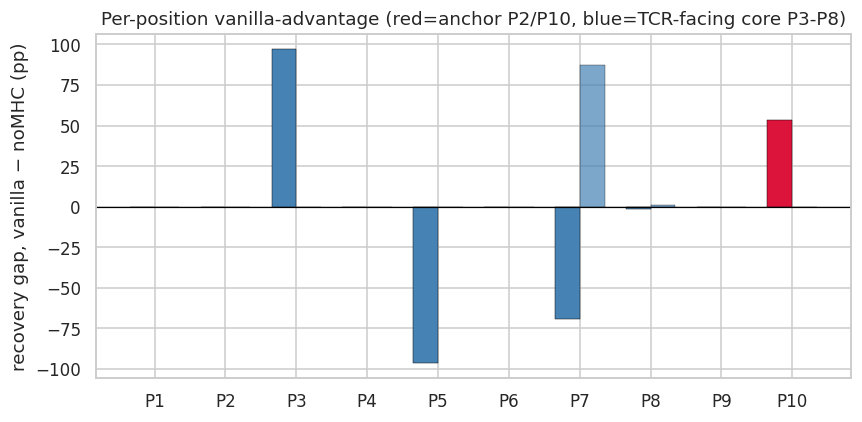

per-crystal, per-anchor breakdown (the pooled mean below can hide a single outlier position):
  6AM5 P2: vanilla-noMHC gap = -0.2pp
  6AM5 P10: vanilla-noMHC gap = +53.7pp
  6AMU P2: vanilla-noMHC gap = +0.0pp
  6AMU P10: vanilla-noMHC gap = +0.0pp

mean vanilla-advantage at anchors (P2,P10), pooled: +13.38pp
mean vanilla-advantage at TCR-facing core (P3-P8): +1.51pp
A gap concentrated in the core (structurally under-determined per notebook 02) rather than at the
anchors (recoverable from geometry alone) would be the memorization fingerprint; a gap that's flat
or anchor-concentrated instead reads as both models doing the structurally-easy part equally well.
NOTE: check the per-crystal breakdown above before trusting the pooled anchor number -- if it is
driven by one (crystal, position) cell rather than being consistent across both anchors x both
crystals, that argues against a general model-level effect (memorized or otherwise).


In [13]:
# 6c. WHERE does the vanilla-noMHC gap sit? anchors (structurally easy, expected) vs the
# TCR-facing core P3-P8 (per per_residue_register.ipynb, structurally the least determined region).
gap_rows = []
for pid in CRYSTALS:
    pv = perpos_df[(perpos_df.crystal==pid)&(perpos_df.model=="vanilla")][[f"P{i+1}" for i in range(L)]].values[0]
    pn = perpos_df[(perpos_df.crystal==pid)&(perpos_df.model=="noMHC")][[f"P{i+1}" for i in range(L)]].values[0]
    gap_rows.append(pv - pn)
gap = np.array(gap_rows)

fig, ax = plt.subplots(figsize=(8,4))
core = list(range(2,8))  # 0-based P3..P8
for i,pid in enumerate(CRYSTALS):
    colors = ["crimson" if (j+1) in ANCHORS else ("steelblue" if j in core else "grey") for j in range(L)]
    ax.bar(np.arange(L)+i*0.35-0.175, gap[i], width=0.35, color=colors, alpha=.7 if i else 1,
           label=pid, edgecolor="k", linewidth=.3)
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}" for i in range(L)])
ax.set_ylabel("recovery gap, vanilla − noMHC (pp)")
ax.set_title("Per-position vanilla-advantage (red=anchor P2/P10, blue=TCR-facing core P3-P8)")
plt.tight_layout(); plt.savefig(FIGDIR/"gap_by_position.png", bbox_inches="tight"); plt.show()

anchor_idx = [a-1 for a in ANCHORS]
anchor_gap = gap[:, anchor_idx].mean()
core_gap = gap[:, core].mean()
print("per-crystal, per-anchor breakdown (the pooled mean below can hide a single outlier position):")
for i, pid in enumerate(CRYSTALS):
    for a in ANCHORS:
        print(f"  {pid} P{a}: vanilla-noMHC gap = {gap[i, a-1]:+.1f}pp")
print(f"\nmean vanilla-advantage at anchors (P2,P10), pooled: {anchor_gap:+.2f}pp")
print(f"mean vanilla-advantage at TCR-facing core (P3-P8): {core_gap:+.2f}pp")
print("A gap concentrated in the core (structurally under-determined per notebook 02) rather than at the")
print("anchors (recoverable from geometry alone) would be the memorization fingerprint; a gap that's flat")
print("or anchor-concentrated instead reads as both models doing the structurally-easy part equally well.")
print("NOTE: check the per-crystal breakdown above before trusting the pooled anchor number -- if it is")
print("driven by one (crystal, position) cell rather than being consistent across both anchors x both")
print("crystals, that argues against a general model-level effect (memorized or otherwise).")